## **Purely Technical Data**

In [ ]:
import pandas as pd
df = pd.read_csv("/content/finbert.csv")

Epoch 1/10
431/431 [==============================] - 16s 27ms/step - loss: 0.0029
Epoch 2/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0019
Epoch 3/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0015
Epoch 4/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0014
Epoch 5/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0013
Epoch 6/10
431/431 [==============================] - 11s 25ms/step - loss: 0.0012
Epoch 7/10
431/431 [==============================] - 11s 25ms/step - loss: 0.0013
Epoch 8/10
431/431 [==============================] - 11s 25ms/step - loss: 0.0012
Epoch 9/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0013
Epoch 10/10
11/11 [==============================] - 1s 17ms/step
Mean Squared Error (MSE): 29.88919166872916
Root Mean Squared Error (RMSE): 5.467100846767797
Mean Absolute Error (MAE): 3.72905572794916


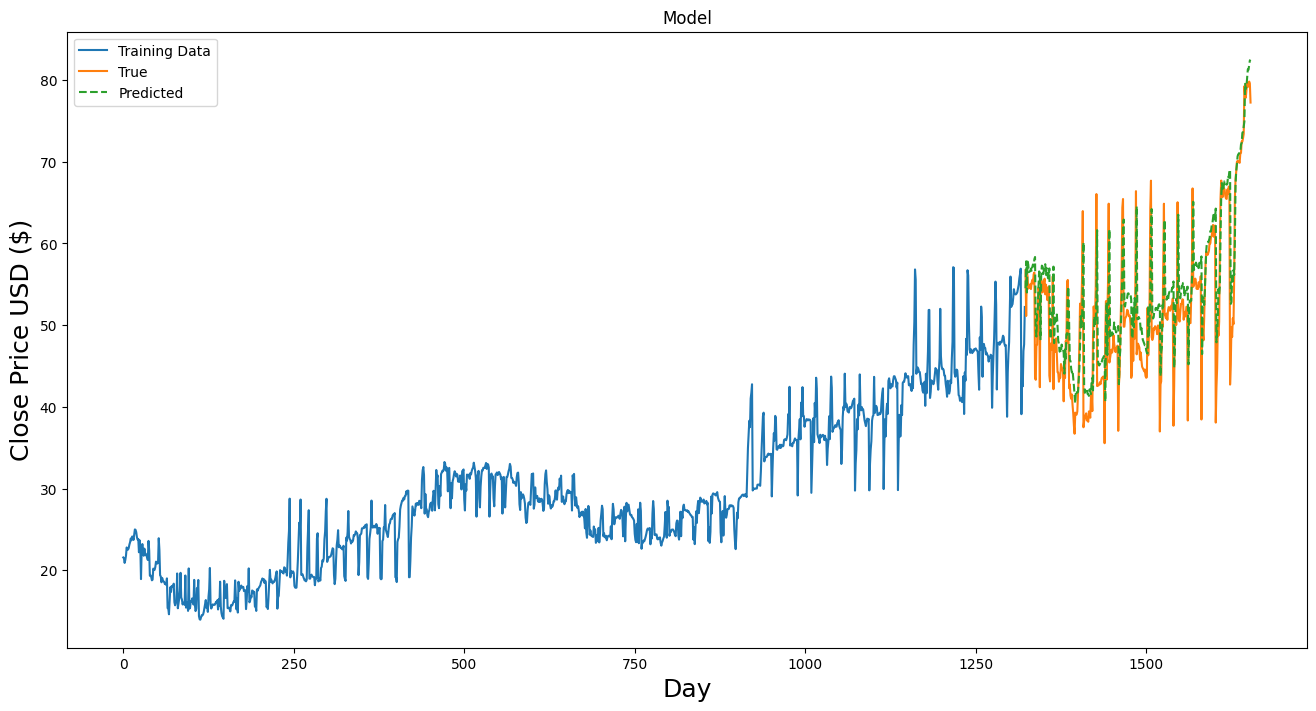

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# Assuming df is your original DataFrame with 'Close' and 'compound' columns

# Create a new dataframe with only the 'Close' column
data = df[['Close']]
dataset = data.values  # Get the values from 'Close' column

# Reshape the dataset into a 2D array (since it's currently 1D)
dataset = dataset.reshape(-1, 1)  # Reshape to (len(dataset), 1)

# Normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(dataset)

# Define the sequence length
sequence_length = 30

# Calculate the training data length
training_data_len = int(len(scaled_data) * 0.8)

# Prepare the training data
x_train, y_train = [], []
for i in range(sequence_length, training_data_len):
    x_train.append(scaled_data[i - sequence_length:i, 0])  # only 'Close' column for input
    y_train.append(scaled_data[i, 0])  # only 'Close' column for the target

x_train, y_train = np.array(x_train), np.array(y_train)

# Build the LSTM model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    LSTM(96, return_sequences=False),
    Dense(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=3, epochs=10)

# Prepare the test data
test_data = scaled_data[training_data_len - sequence_length:]
x_test, y_test = [], []
for i in range(sequence_length, len(test_data)):
    x_test.append(test_data[i - sequence_length:i, 0])  # only 'Close' column for input
    y_test.append(test_data[i, 0])  # only 'Close' column for the target

x_test, y_test = np.array(x_test), np.array(y_test)

# Predict the next day's Close for the test data
lstm_predictions = model.predict(x_test)

# Inverse scaling to get the actual predicted values
predicted_close = scaler.inverse_transform(lstm_predictions).flatten()
actual_test_values = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Calculate MSE, RMSE, and MAE
mse = np.mean((predicted_close - actual_test_values)**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(predicted_close - actual_test_values))

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)

# Plotting
plt.figure(figsize=(16, 8))
plt.title('Model')
plt.xlabel('Day', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(data['Close'][:training_data_len], label='Training Data')  # Plotting training data
plt.plot(range(training_data_len, len(data['Close'])), data['Close'][training_data_len:], label='True')  # Plotting test data
plt.plot(range(training_data_len, len(data['Close'])), predicted_close, label='Predicted', linestyle='--')
plt.legend()
plt.show()


## **NLTK Sentiment**

In [ ]:
df_nltk = pd.read_csv("/content/nltk.csv")

Epoch 1/10
431/431 [==============================] - 16s 26ms/step - loss: 0.0034
Epoch 2/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0020
Epoch 3/10
431/431 [==============================] - 11s 25ms/step - loss: 0.0017
Epoch 4/10
431/431 [==============================] - 11s 25ms/step - loss: 0.0015
Epoch 5/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0013
Epoch 6/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0014
Epoch 7/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0014
Epoch 8/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0014
Epoch 9/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0013
Epoch 10/10
11/11 [==============================] - 1s 20ms/step
Mean Squared Error (MSE): 25.277124348023516
Root Mean Squared Error (RMSE): 5.027636059623202
Mean Absolute Error (MAE): 3.0896599514024183


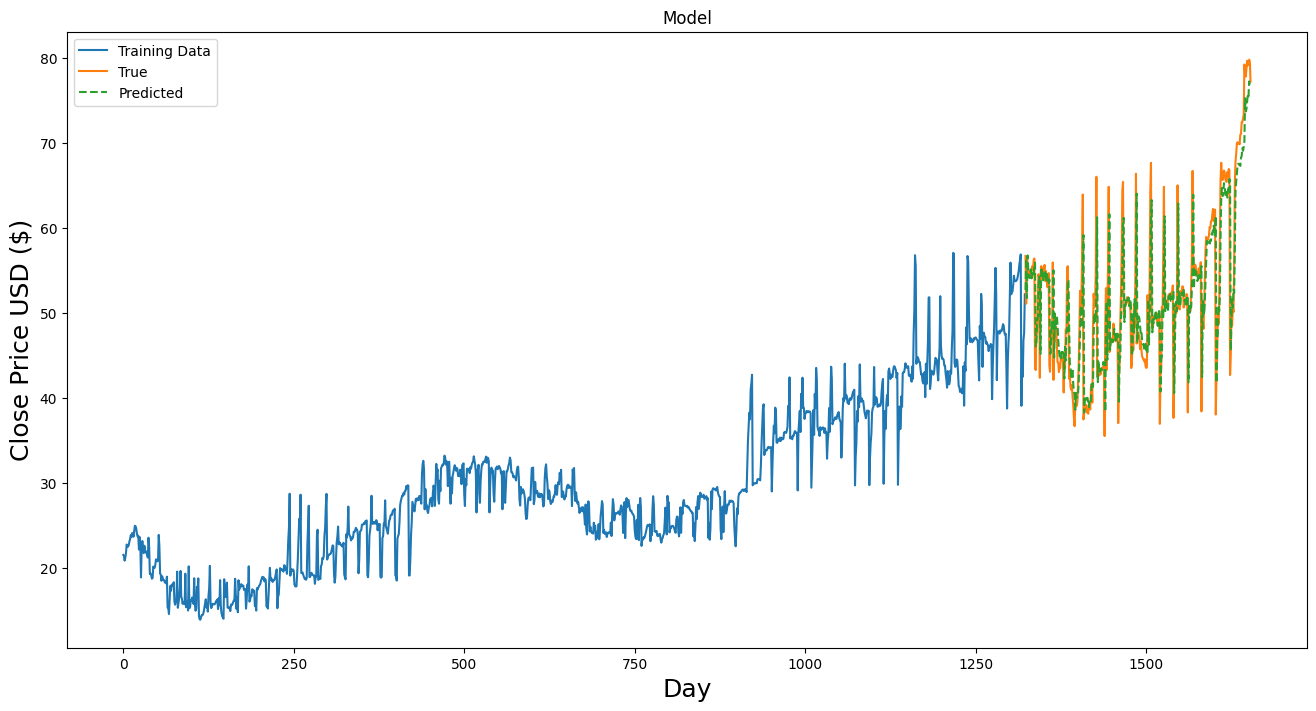

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# Assuming df is your original DataFrame with 'Close' and 'compound' columns

# Create a new dataframe with only the 'Close' and 'compound' columns
data = df_nltk[['Close', 'compound']]
dataset = data.values

# Normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(dataset)

# Define the sequence length
sequence_length = 30

# Calculate the training data length
training_data_len = int(len(scaled_data) * 0.8)

# Prepare the training data
x_train, y_train = [], []
for i in range(sequence_length, training_data_len):
    x_train.append(scaled_data[i - sequence_length:i, :])  # includes both Close and compound
    y_train.append(scaled_data[i, 0])  # only Close for the target

x_train, y_train = np.array(x_train), np.array(y_train)

# Build the LSTM model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])),
    LSTM(96, return_sequences=False),
    Dense(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=3, epochs=10)

# Prepare the test data
test_data = scaled_data[training_data_len - sequence_length:]
x_test, y_test = [], []
for i in range(sequence_length, len(test_data)):
    x_test.append(test_data[i - sequence_length:i, :])  # includes both Close and compound
    y_test.append(test_data[i, 0])  # only Close for the target

x_test, y_test = np.array(x_test), np.array(y_test)

# Predict the next day's Close for the test data
lstm_predictions = model.predict(x_test)

# Inverse scaling to get the actual predicted values
predicted_close = scaler.inverse_transform(np.concatenate((lstm_predictions.reshape(-1, 1), np.zeros((len(lstm_predictions), 1))), axis=1))[:, 0]
actual_test_values = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), 1))), axis=1))[:, 0]
# Calculate MSE, RMSE, and MAE
mse = np.mean((predicted_close - actual_test_values)**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(predicted_close -actual_test_values))

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)

# Plotting
plt.figure(figsize=(16, 8))
plt.title('Model')
plt.xlabel('Day', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(data['Close'][:training_data_len], label='Training Data')  # Plotting training data
plt.plot(range(training_data_len, len(data['Close'])), data['Close'][training_data_len:], label='True')  # Plotting test data
plt.plot(range(training_data_len, len(data['Close'])), predicted_close, label='Predicted', linestyle='--')
plt.legend()
plt.show()


## **FinBERT Sentiment**

In [ ]:
df_finbert = pd.read_csv("/content/finbert.csv")

Epoch 1/10
433/433 [==============================] - 15s 27ms/step - loss: 0.0032
Epoch 2/10
433/433 [==============================] - 11s 26ms/step - loss: 0.0021
Epoch 3/10
433/433 [==============================] - 11s 26ms/step - loss: 0.0019
Epoch 4/10
433/433 [==============================] - 11s 26ms/step - loss: 0.0017
Epoch 5/10
433/433 [==============================] - 11s 26ms/step - loss: 0.0016
Epoch 6/10
433/433 [==============================] - 11s 24ms/step - loss: 0.0014
Epoch 7/10
433/433 [==============================] - 11s 26ms/step - loss: 0.0014
Epoch 8/10
433/433 [==============================] - 11s 26ms/step - loss: 0.0013
Epoch 9/10
433/433 [==============================] - 11s 26ms/step - loss: 0.0014
Epoch 10/10
11/11 [==============================] - 0s 19ms/step
161.92260791844913 12.724881450074461 9.770181003503748


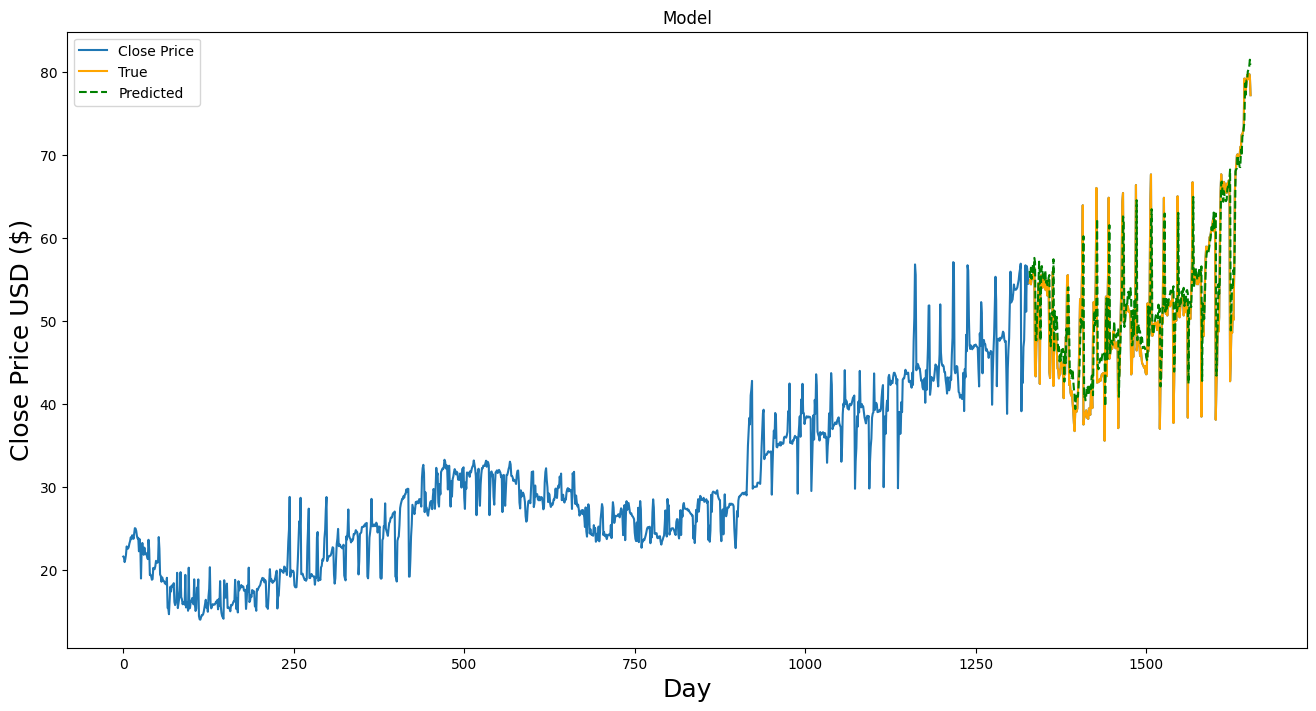

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
#DistilRoberta
# Define look back
look_back = 30

# Function to create dataset with look back
def create_dataset(X, y, look_back):
    X_data, y_data = [], []
    for i in range(len(X) - look_back):
        X_data.append(X[i:(i + look_back)])
        y_data.append(y[i + look_back])
    return np.array(X_data), np.array(y_data)

# Extract features and target variable
X = df_finbert[['Close', 'Neutral', 'Positive', 'Negative']].values
y = df_finbert['Close'].values

# Normalize features
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1,1)).flatten()

# Create dataset with look back
X_data, y_data = create_dataset(X_scaled, y_scaled, look_back)

# Split data into train and test sets (80:20, with the last 20% as test data)
split_index = int(len(X_data) * 0.8)
X_train, X_test = X_data[:split_index], X_data[split_index:]
y_train, y_test = y_data[:split_index], y_data[split_index:]

# Build LSTM model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(96, return_sequences=False),
    Dense(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=3, verbose=1)

# Predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse scaling for predictions
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

actual_test_values = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), 1))), axis=1))[:, 0]
# Calculate MSE
mse = np.mean((test_predict - actual_test_values)**2)

# Calculate RMSE
rmse = np.sqrt(np.mean((test_predict - actual_test_values)**2))
mae = np.mean(np.abs(test_predict -actual_test_values))

print(mse, rmse, mae)


# Plotting
plt.figure(figsize=(16, 8))
plt.title('Model')
plt.xlabel('Day', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)

# Plotting entire close price history
plt.plot(df['Close'], label='Close Price')

# Plotting test data
plt.plot(range(split_index + look_back, len(df['Close'])), df['Close'][split_index + look_back:], label='True', color='orange')

# Plotting predicted values
plt.plot(range(split_index + look_back, len(df['Close'])), test_predict, label='Predicted', linestyle='--', color='green')

plt.legend()
plt.show()


## **DistilROBERTA**

In [ ]:
df_di = pd.read_csv("/content/distilroberta.csv")

Epoch 1/10
433/433 [==============================] - 16s 27ms/step - loss: 0.0035
Epoch 2/10
433/433 [==============================] - 13s 29ms/step - loss: 0.0022
Epoch 3/10
433/433 [==============================] - 11s 26ms/step - loss: 0.0022
Epoch 4/10
433/433 [==============================] - 12s 27ms/step - loss: 0.0018
Epoch 5/10
433/433 [==============================] - 11s 27ms/step - loss: 0.0015
Epoch 6/10
433/433 [==============================] - 11s 26ms/step - loss: 0.0015
Epoch 7/10
433/433 [==============================] - 11s 25ms/step - loss: 0.0013
Epoch 8/10
433/433 [==============================] - 12s 27ms/step - loss: 0.0014
Epoch 9/10
433/433 [==============================] - 11s 26ms/step - loss: 0.0013
Epoch 10/10
11/11 [==============================] - 0s 18ms/step
158.77763974593134 12.600699970475105 9.639871267384654


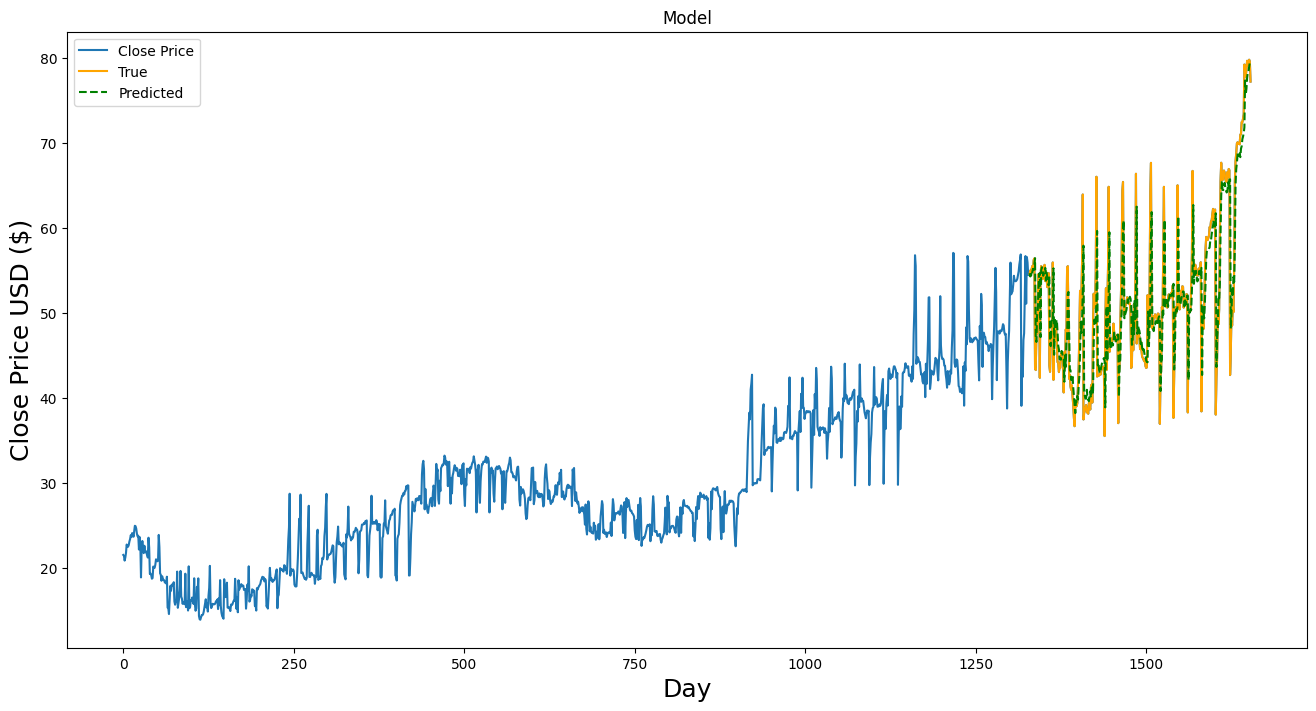

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
#DistilRoberta
# Define look back
look_back = 30

# Function to create dataset with look back
def create_dataset(X, y, look_back):
    X_data, y_data = [], []
    for i in range(len(X) - look_back):
        X_data.append(X[i:(i + look_back)])
        y_data.append(y[i + look_back])
    return np.array(X_data), np.array(y_data)

# Extract features and target variable
X = df_di[['Close', 'Neutral', 'Positive', 'Negative']].values
y = df_di['Close'].values

# Normalize features
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.reshape(-1,1)).flatten()

# Create dataset with look back
X_data, y_data = create_dataset(X_scaled, y_scaled, look_back)

# Split data into train and test sets (80:20, with the last 20% as test data)
split_index = int(len(X_data) * 0.8)
X_train, X_test = X_data[:split_index], X_data[split_index:]
y_train, y_test = y_data[:split_index], y_data[split_index:]

# Build LSTM model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(96, return_sequences=False),
    Dense(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=3, verbose=1)

# Predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse scaling for predictions
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

actual_test_values = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), 1))), axis=1))[:, 0]
# Calculate MSE
mse = np.mean((test_predict - actual_test_values)**2)

# Calculate RMSE
rmse = np.sqrt(np.mean((test_predict - actual_test_values)**2))
mae = np.mean(np.abs(test_predict -actual_test_values))

print(mse, rmse, mae)


# Plotting
plt.figure(figsize=(16, 8))
plt.title('Model')
plt.xlabel('Day', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)

# Plotting entire close price history
plt.plot(df['Close'], label='Close Price')

# Plotting test data
plt.plot(range(split_index + look_back, len(df['Close'])), df['Close'][split_index + look_back:], label='True', color='orange')

# Plotting predicted values
plt.plot(range(split_index + look_back, len(df['Close'])), test_predict, label='Predicted', linestyle='--', color='green')

plt.legend()
plt.show()


## **Sentiment Label**

In [ ]:
import pandas as pd
df_label = pd.read_csv("/content/nltk.csv")

Epoch 1/10
431/431 [==============================] - 19s 27ms/step - loss: 0.0033
Epoch 2/10
431/431 [==============================] - 12s 27ms/step - loss: 0.0021
Epoch 3/10
431/431 [==============================] - 12s 27ms/step - loss: 0.0018
Epoch 4/10
431/431 [==============================] - 12s 27ms/step - loss: 0.0016
Epoch 5/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0013
Epoch 6/10
431/431 [==============================] - 11s 26ms/step - loss: 0.0013
Epoch 7/10
431/431 [==============================] - 12s 27ms/step - loss: 0.0013
Epoch 8/10
431/431 [==============================] - 12s 27ms/step - loss: 0.0013
Epoch 9/10
431/431 [==============================] - 11s 27ms/step - loss: 0.0012
Epoch 10/10
11/11 [==============================] - 1s 22ms/step
Mean Squared Error (MSE): 25.68898633388742
Root Mean Squared Error (RMSE): 5.068430361945148
Mean Absolute Error (MAE): 3.1542999646030214


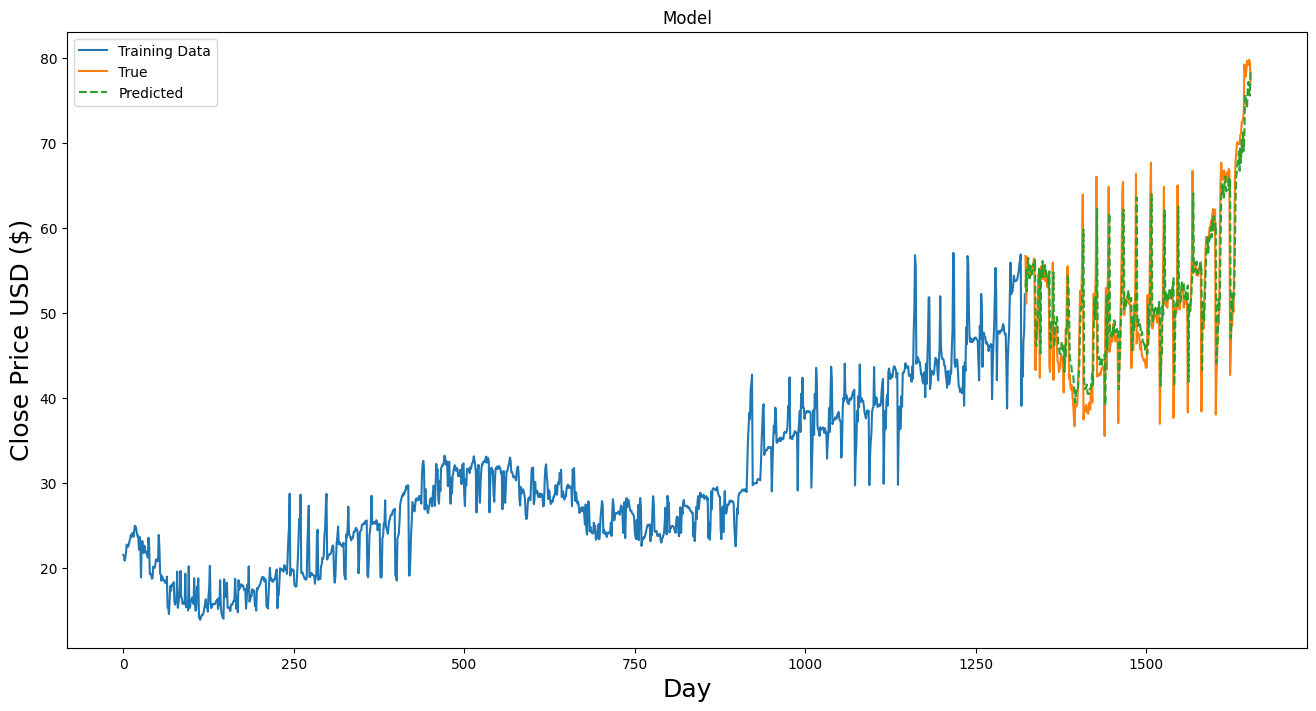

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# Assuming df is your original DataFrame with 'Close' and 'compound' columns

# Create a new dataframe with only the 'Close' and 'compound' columns
data = df[['Close', 'label']]
dataset = data.values

# Normalize the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(dataset)

# Define the sequence length
sequence_length = 30

# Calculate the training data length
training_data_len = int(len(scaled_data) * 0.8)

# Prepare the training data
x_train, y_train = [], []
for i in range(sequence_length, training_data_len):
    x_train.append(scaled_data[i - sequence_length:i, :])  # includes both Close and compound
    y_train.append(scaled_data[i, 0])  # only Close for the target

x_train, y_train = np.array(x_train), np.array(y_train)

# Build the LSTM model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])),
    LSTM(96, return_sequences=False),
    Dense(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=3, epochs=10)

# Prepare the test data
test_data = scaled_data[training_data_len - sequence_length:]
x_test, y_test = [], []
for i in range(sequence_length, len(test_data)):
    x_test.append(test_data[i - sequence_length:i, :])  # includes both Close and compound
    y_test.append(test_data[i, 0])  # only Close for the target

x_test, y_test = np.array(x_test), np.array(y_test)

# Predict the next day's Close for the test data
lstm_predictions = model.predict(x_test)

# Inverse scaling to get the actual predicted values
predicted_close = scaler.inverse_transform(np.concatenate((lstm_predictions.reshape(-1, 1), np.zeros((len(lstm_predictions), 1))), axis=1))[:, 0]
actual_test_values = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), 1))), axis=1))[:, 0]
# Calculate MSE, RMSE, and MAE
mse = np.mean((predicted_close - actual_test_values)**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(predicted_close -actual_test_values))

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)

# Plotting
plt.figure(figsize=(16, 8))
plt.title('Model')
plt.xlabel('Day', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(data['Close'][:training_data_len], label='Training Data')  # Plotting training data
plt.plot(range(training_data_len, len(data['Close'])), data['Close'][training_data_len:], label='True')  # Plotting test data
plt.plot(range(training_data_len, len(data['Close'])), predicted_close, label='Predicted', linestyle='--')
plt.legend()
plt.show()
